# BEE 4750 Homework 1: Introduction to Using Julia

**Name**:

**ID**:

> **Due Date**
>
> Thursday, 9/11/25, 9:00pm

## Overview

### Instructions

-   Problem 1 consist of a series of code snippets for you to interpret
    and debug. You will be asked to identify relevant error(s) and fix
    the code.
-   Problem 2 asks you to write code to implement several simple
    functions using more general programming and some which are unique
    to Julia (which might mean that you need to look at the
    documentation or use Julia’s help function, which is accessed with
    `?`, e.g. `?sum` for help with the `sum()` function) or to analyze
    Julia syntax.
-   Problem 3 asks you to convert a verbal description of a wastewater
    treatment system into a Julia function, and then to use that
    function to explore the impact of different wastewater allocation
    strategies.

### Load Environment

The following code loads the environment and makes sure all needed
packages are installed. This should be at the start of most Julia
scripts.

In [19]:
import Pkg
Pkg.activate(@__DIR__)
Pkg.instantiate()
Pkg.add("DataFrames")

  Activating project at `~/BEE 4750 /HW 1/bee4750-hw1-rv297`
    Updating registry at `~/.julia/registries/General.toml`
   Resolving package versions...
   Installed InlineStrings ─────────────── v1.4.5
   Installed DataValueInterfaces ───────── v1.0.0
   Installed PooledArrays ──────────────── v1.4.3
   Installed SentinelArrays ────────────── v1.4.8
   Installed InvertedIndices ───────────── v1.3.1
   Installed TableTraits ───────────────── v1.0.1
   Installed PrettyTables ──────────────── v2.4.0
   Installed DataFrames ────────────────── v1.7.1
   Installed Crayons ───────────────────── v4.1.1
   Installed Tables ────────────────────── v1.12.1
   Installed IteratorInterfaceExtensions ─ v1.0.0
   Installed StringManipulation ────────── v0.4.1
    Updating `~/BEE 4750 /HW 1/bee4750-hw1-rv297/Project.toml`
  [a93c6f00] + DataFrames v1.7.1
    Updating `~/BEE 4750 /HW 1/bee4750-hw1-rv297/Manifest.toml`
  [a8cc5b0e] + Crayons v4.1.1
  [a93c6f00] + DataFrames v1.7.1
  [e2d170a0] + DataVal

Standard Julia practice is to load all needed packages at the top of a
file. If you need to load any additional packages in any assignments
beyond those which are loaded by default, feel free to add a `using`
statement, though [you may need to install the
package](https://viveks.me/environmental-systems-analysis/tutorials/julia-basics.html#package-management).

In [27]:
using Random
using Plots
using GraphRecipes
using LaTeXStrings
using Distributions

In [28]:
# this sets a random seed, which ensures reproducibility of random number generation. You should always set a seed when working with random numbers.
Random.seed!(1)

TaskLocalRNG()

## Problems (Total: 30 Points)

### Problem 1 (12 points)

The following subproblems all involve code snippets that require
debugging. You are encouraged to use online resources (*e.g.* Julia
documentation and forums, Stack Overflow, Reddit, etc) to help find
diagnose error messages and find solutions, but make sure that you
clearly document which resources you used and how you used them.

#### Problem 1.1

You’ve been tasked with writing code to identify the minimum value in an
array. You cannot use a predefined function. Your colleague suggested
the function below, but it does not return the minimum value.

In [29]:
function minimum(array)
    # initialize the minimum value counter
    min_value = array[1]
    # update minimum values
    for i in 1:length(array)
        if array[i] < min_value
            min_value = array[i]
        end
    end
    # return found minimum
    return min_value
end

array_values = [89, 90, 95, 100, 100, 78, 99, 98, 100, 95]
@show minimum(array_values);

minimum(array_values) = 78


What is the logical flaw in the code? Fix it and show that your fixed
code solves the problem.

**Solution:**

The flaw in the original code was initializing min_value to 0. This can incorrectly return 0 if, for example, the array only contains positive numbers because there would never be a value smaller than 0.

To fix this issue I initialized min_value to the first element of the array (array[1]). This way the starting value is always valid and within the array. The loop then correctly updates min_value as it goes through each element in the array and returning the true minimum value.
#### Problem 1.2

Your team is trying to compute the average grade for your class, but the
following code produces an `UndefVarError`.

In [30]:
# enter student grade vector
student_grades = [89, 90, 95, 100, 100, 78, 99, 98, 100, 95]
# compute class average
function class_average(grades)
  average_grade = mean(student_grades)
  return average_grade
end
average_grade = class_average(student_grades)
@show average_grade;

average_grade = 94.4


What does this `UndefVarError` mean? Why does this code produce one? Fix
the error and solve the problem.

According to Stack Overflow 'UndefVarError' has to do with the scope of variables. In the code above, average_grade only exists in the function class_average. So calling it in the global/main scope will not work since it does not exist there. To fix this, we can call the correct average value in the global scope using the function class_average and store it in the variable average_grade. Then, Julia will correctly show the average grade as 94.4 with no errors!

#### Problem 1.3

Your team wants to know the expected payout of an old Italian dice game
called *passadieci* (which was analyzed by Galileo as one of the first
examples of a rigorous study of probability). The goal of passadieci is
to get at least an 11 from rolling three fair, six-sided dice. Your
strategy is to compute the average wins from 1,000 trials, but the code
you’ve written below produces a `MethodError`.

In [31]:
# function to simulate a passadieci roll: 3 6-sided dice
function passadieci()
    # this rand() call samples 3 values from the vector [1, 6]
    roll = rand(1:6, 3) 
    return roll
end
# set number of trials and initialize outcome vector
n_trials = 1_000
outcomes = zeros(Int, n_trials)
# simulate number of passadieci rolls and count wins
for i = 1:n_trials
    outcomes[i] = (sum(passadieci()) > 11)
end
win_prob = sum(outcomes) / n_trials # compute average number of wins
@show win_prob;

win_prob = 0.382


What does this `MethodError` mean? Why does this code produce one? Fix the error and solve the problem.

I was not able to find much on StackOverflow or Julia documentation/forums so I asked ChatGPT what 'MethodError' means. It stated that Julia could not find any function defintion/method that matches the arguments given. So I realized that in this case, zeros(n_trials) returned the integer 0 but the code requires for an array when calling outcomes[i], hence the 'MethodError. To fix this, I made outcomes = zeros(Int, n_trials) so that outcomes is now an integer array of length n_trials. At this point, outcomes[i] can be called properly.


#### Problem 1.4

You’re interested in writing some code to remove the mean of a vector
from all of its components. You’ve written the following code and tried
to test it on a random vector, but your code returns a `MethodError`.

In [32]:
# function to remove mean from a vector
function remove_mean(vect)
    # fucntion to compute the mean
    function compute_mean(vect)
        element_sum = 0 # initialize sum
        # compute mean and return
        for v in vect
            element_sum += v
        end
        return element_sum / length(vect)
    end

    m = compute_mean(vect) # compute mean
    # return demeaned vector

    new_vect = copy(vect)
    for i in 1:length(vect)
        new_vect[i] = vect[i] - m
    end
    return new_vect
end

random_vect = rand(1_000)
@show remove_mean(random_vect)

remove_mean(random_vect) = [0.41919142411294885, -0.04477120169153992, -0.15987063495003362, -0.3165390583665356, -0.04345183269168251, 0.4600428661267356, -0.4814808404373695, 0.05265958609672772, -0.019033198532207418, 0.11752715148103854, -0.2530763598508532, -0.3987461186978969, -0.4051668577883766, -0.14537708102382318, -0.021518846454485097, 0.2393846697392613, -0.13828803455335292, 0.28932439329980286, -0.44190436643288566, -0.41462031768210295, -0.1481768399620188, -0.4467685839176895, 0.16354702958537648, -0.324893449617489, -0.22436376824831783, 0.18691945805247367, -0.2843753736563317, 0.30832500598057266, 0.2757047181327851, 0.44059511305789445, 0.12832592230812423, 0.1935791502153814, 0.2896691235161918, -0.05389047441266104, 0.1218772930619838, -0.24482626621372394, 0.22316484875624798, 0.4597763846856109, -0.33758006386107464, 0.19126011359930628, -0.3305504301513418, -0.20836963537351572, 0.4435549655840101, 0.14379124696474477, 0.3902589386802747, -0.2551400209756388, 

1000-element Vector{Float64}:
  0.41919142411294885
 -0.04477120169153992
 -0.15987063495003362
 -0.3165390583665356
 -0.04345183269168251
  0.4600428661267356
 -0.4814808404373695
  0.05265958609672772
 -0.019033198532207418
  0.11752715148103854
  ⋮
  0.1701029484937252
 -0.45332724205642416
 -0.4743008238822817
 -0.4129715382326393
  0.23830378602543056
  0.06271140871181402
  0.11506229654060751
 -0.1638906511382653
 -0.0897920909169232

What does this `MethodError` mean? Why does this code produce one? Fix
the error and solve the problem.

As stated in problem 1.3, 'MethodError' means that Julia could not find any function defintion/method that matches the arguments given. In this case, the error is thrown because vect - m is trying to subtract a scalar from a vector, which is not possible. To fix this, I made a new vector, new_vect, to modify and subtract the mean from. I did this by copying vect with the method copy(), which I found on Julia documentation. Then I used a for loop to index through and subtract m from each element in new_vect, which now works because it is a scalar subtracted from a scalar. Finally, new_vect returns the correct vector we are looking for. 

### Problem 2 (18 points)

Cheap Plastic Products, Inc. is operating a plant that produces
$100 \text{m}^3\text{/day}$ of wastewater that is discharged into
Pristine Brook. The wastewater contains $1 \text{kg/m}^3$ of YUK, a
toxic substance. The US Environmental Protection Agency has imposed an
effluent standard on the plant prohibiting discharge of more than
$20 \text{kg/day}$ of YUK into Pristine Brook.

Cheap Plastic Products has analyzed two methods for reducing its
discharges of YUK. Method 1 is land disposal, which costs $X_1^2/20$
dollars per day, where $X_1$ is the amount of wastewater disposed of on
the land ($\text{m}^3\text{/day}$). With this method, 20% of the YUK
applied to the land will eventually drain into the stream (*i.e.*, 80%
of the YUK is removed by the soil).

Method 2 is a chemical treatment procedure which costs \$1.50 per
$\text{m}^3$ of wastewater treated. The chemical treatment has an
efficiency of $e= 1 - 0.005X_2$, where $X_2$ is the quantity of
wastewater ($\text{m}^3\text{/day}$) treated. For example, if
$X_2 = 50 \text{m}^3\text{/day}$, then $e = 1 - 0.005(50) = 0.75$, so
that 75% of the YUK is removed.

Cheap Plastic Products is wondering how to allocate their wastewater
between these three disposal and treatment methods (land disposal,
chemical treatment, and direct disposal) to meet the effluent standard
while keeping costs manageable.

The flow of wastewater through this treatment system is shown in
<a href="#fig-wastewater" class="quarto-xref">Figure 1</a>. Modify the
edge labels (by editing the `edge_labels` dictionary in the code
producing <a href="#fig-wastewater" class="quarto-xref">Figure 1</a>) to
show how the wastewater allocations result in the final YUK discharge
into Pristine Brook. For the `edge_label` dictionary, the tuple $(i, j)$
corresponds to the arrow going from node $i$ to node $j$. The syntax for
any entry is `(i, j) => "label text"`, and the label text can include
mathematical notation if the string is prefaced with an `L`, as in
`L"x_1"` will produce $x_1$.

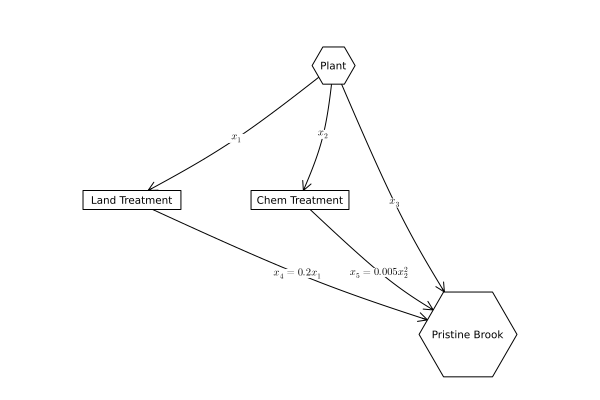

In [5]:
using Random
using Plots
using GraphRecipes
using LaTeXStrings
using Distributions
A = [0 1 1 1;
    0 0 0 1;
    0 0 0 1;
    0 0 0 0]

names = ["Plant", "Land Treatment", "Chem Treatment", "Pristine Brook"]
# modify this dictionary to add labels
edge_labels = Dict((1, 2) => L"x_1", (1,3) => L"x_2", (1, 4) => L"x_3",(2, 4) => L"x_4 = 0.2x_1",(3, 4) => L"x_5 = 0.005x_2^2")
shapes=[:hexagon, :rect, :rect, :hexagon]
xpos = [0, -1.5, -0.25, 1]
ypos = [1, 0, 0, -1]

p = graphplot(A, names=names,edgelabel=edge_labels, markersize=0.15, markershapes=shapes, markercolor=:white, x=xpos, y=ypos)
display(p)

**Explanation of Figure 1**

This image is showing the concentrations of YUK from when they leave the Plant until they reach Pristine Brook. The concentrations that leave the plant are : $x_1$ , $x_2$ , and $x_3$ . The concentrations that reach Pristine Brook include: $x_4$ , $x_5$ , and $x_3$. $x_1$ and $x_2$ change after going through treatment, as shown above.

#### Problem 2.1

Formulate a mathematical model for the treatment cost and the amount of
YUK that will be discharged into Pristine Brook based on the wastewater
allocations. This is best done with some equations and supporting text
explaining the derivation. Make sure you include, as additional
equations in the model, any needed constraints on relevant values. You
can find some basics on writing mathematical equations using the LaTeX
typesetting syntax
[here](https://viveks.me/environmental-systems-analysis/tutorials/latex-notebook.qmd),
and a cheatsheet with LaTeX commands can be found on the course
website’s [Resources
page](https://viveks.me/environmental-systems-analysis/resources/markdown.qmd).

**Solution:**

The wastewater contains $1 kg/m^3$ so when $x_1$ $m^3$/day leaves the plant and heads toward the land treatment the quantity of YUK is also $x_1$ kg/day. Once this wastewater has passed the land treatment, 80% of the YUK is removed by the soil so $x_4 = 0.2 x_1$ kg/day. Similarly, the $x_2$ wastewater flow has $x_2$ kg/day of YUK. After it passes the chemical treatment with efficiency e = 1 - 0.005 $x_2$ , it will have a new concentration of YUK $x_5$ = (1-e) $x_2$ = 0.005 $x_2^2$ . Finally the third stream, $x_3$ , leaving the plant does not go through any treatment so it will have the same concentration of $x_3$ kg/day of YUK. The final amount of YUK that will be discharged into the Pristine Brook will be 0.2 $x_1$ + 0.005 $x_2^2$ + $x_3$ ≤ 20 kg/day with two constraints: $x_1$ + $x_2$ + $x_3$ = 100 $m^3/day$ and the final amount of YUK must be ≤ 20 kg/day.

The treatment cost of the water treatment is $x_1^2$ / 20 + $1.50 $x_2$ , which includes the cost of land and chemical treatment. 

**In summary, these are the equations to model the YUK concentrations going into Pristine Brook:**

Total YUK concentrations = 0.2 $x_1$ + 0.005 $x_2^2$ + $x_3$ 

Constraints: 

1. $x_1$ + $x_2$ + $x_3$ = 100 $m^3/day$
2. Total YUK concentrations must be ≤ 20 kg/day


#### Problem 2.2

Implement your systems model as a Julia function which computes the
resulting YUK discharge and cost for a particular treatment plan. You
can return multiple values from a function with a
[tuple](https://docs.julialang.org/en/v1/manual/functions/#Tuples-1), as
in:

In [34]:
function multiple_return_values(x, y)
    return (x+y, x*y)
end

a, b = multiple_return_values(2, 5)
@show a;
@show b;

a = 7
b = 10


To evalute the function over vectors of inputs, you can *broadcast* the
function by adding a decimal `.` before the function arguments and
accessing the resulting values by writing a *comprehension* to loop over
the individual outputs in the vector:

In [35]:
x = [1, 2, 3, 4, 5]
y = [6, 7, 8, 9, 10]

output = multiple_return_values.(x, y)
a = [out[1] for out in output]
b = [out[2] for out in output]
@show a;
@show b;

a = [7, 9, 11, 13, 15]
b = [6, 14, 24, 36, 50]


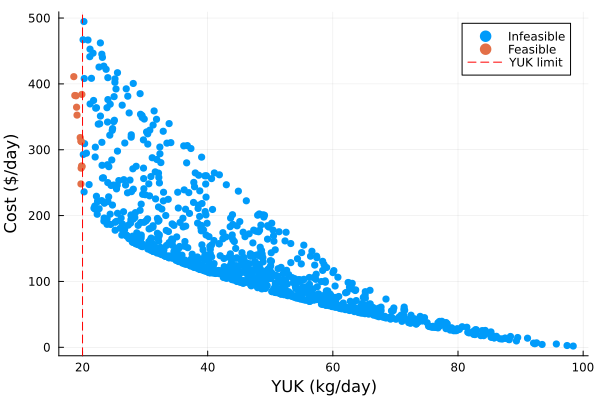

13×5 DataFrame
 Row │ x1       x2       x3        discharge  cost    
     │ Float64  Float64  Float64   Float64    Float64 
─────┼────────────────────────────────────────────────
   1 │ 74.572   23.3048  2.12323     19.7532  313.006
   2 │ 82.4794  16.2946  1.22596     19.0494  364.585
   3 │ 85.4656  12.5129  2.0215      19.8975  383.988
   4 │ 80.7119  17.9113  1.37688     19.1233  352.587
   5 │ 84.9461  14.0713  0.982667    18.9619  381.899
   6 │ 67.0319  31.5847  1.38339     19.7777  272.041
   7 │ 61.8042  38.0466  0.149248    19.7478  248.058
   8 │ 75.4528  22.5505  1.99664     19.6298  318.482
   9 │ 74.4768  23.3508  2.17236     19.794   312.366
  10 │ 67.6     30.6945  1.70551     19.9363  274.53
  11 │ 84.9703  14.2733  0.756385    18.7691  382.408
  12 │ 88.8396  10.9194  0.240975    18.6051  411.003
  13 │ 67.7337  30.6609  1.60541     19.8526  275.384

In [ ]:
function yuk_output(x1, x2, Q = 100)
    x3 = 100 - x1 - x2 #find x3 - water receiving NO treatment
    discharge = 0.2 * x1 + 0.005 * x2^2 + x3 #total YUK concentration going into Pristine Brook (kg/day)
    cost = ( x1^2 / 20 ) + 1.50 * x2 #total cost of the water treatment for x1 and x2 ($/day)

    #Discharge of YUK into the Pristine Brok must be less than 20 kg/day, this part of the code shows whether this standard is met by the given wastewater allocations in the system
    if discharge <= 20 #if YUK concentration is no more than 20kg/day, then standard is met
        meets_standard = true
    else 
        meets_standard = false #if it is more than 20kg/day, standard is NOT met
    end
    return(discharge, cost, meets_standard) 
    
end

"""
x1 = 20
x2 = 30
(d, c, m) = yuk_output(x1, x2, 100)
@show d;
@show c;
@show m;
"""

# Problem 2.3
using Random, Distributions, Plots
Random.seed!(42)
Q = 100 # max flow leaving plant
N = 1000 # N of trials

# set up the random trials
X = rand(Dirichlet(3,1.0), N)
x1 = Q .* X[1, :]
x2 = Q .* X[2, :]

d = similar(x1) # discharge
c = similar(x2) # cost
s = falses(N) # whether discharge into Pristine Brook meets the standard

for i in 1:N
    d[i], c[i], s[i] = yuk_output(x1[i], x2[i], Q) # test the model for each of the random trials
end

# Find all the tests that do NOT exceed 20 kg.day of YUK into Pristine Brook
using DataFrames 
feasible_trials = DataFrame( x1 = x1[s], x2 = x2[s], x3 = 100 .- x1[s] .- x2[s], discharge = d[s], cost = c[s])
print(feasible_trials)

# Scatter plot of all trials
scatter(d[.!s], c[.!s], label="Infeasible", ms=4, markerstrokewidth=0,
        xlabel="YUK (kg/day)", ylabel="Cost (\$/day)") # plot all points that are above the 20 kg/day YUK concentration
scatter!(d[s], c[s], label="Feasible", ms=4, markerstrokewidth=0) # plot all points equal to or below 20 kg/day YUK concentration
vline!([20], linestyle=:dash, color=:red, label="YUK limit") # mark the 20 kg/day limit with a vertical red line
display(current())

Make sure you comment your code appropriately to make it clear what is going on and why.

**Solution**

This model takes in the parameters of $x_1$ , $x_2$ , and sets the total flow leaving the plant as 100 $m^3$ /day. From these inputs, $x_3$ can be found by subtracting $x_1$ and $x_2$ from the total flow of 100 $m^3$ /day. Then, the discharge and cost quantities can be found using these equations:

1. Discharge = 0.2 * $x_1$ + 0.005 * $x_2^2$ + $x_3$
2. Cost = ( $x_1$ / 20 ) + 1.50 * $x_2$ 

The discharge equation is explained in above in problem 2.1 and the cost equation is derived from the given cost of $x_1$ / 20 for the land treatment and $1.50 per kg of wastewater being treated chemically from the $x_2$ stream. 

Finally, the output of this model displays whether or not these inputs meet the requirement of having no more than 20 kg/day enter Pristine Brook. If it does meet this standard, the model returns true, but if it does not then false.

#### Problem 2.3

Use your function to experiment with 1,000 different combinations of
wastewater discharge and treatment. You can do this with either a grid
search or by sampling from a [Dirichlet
distribution](https://en.wikipedia.org/wiki/Dirichlet_distribution) (a
$\text{Dirichlet}(1, n)$ distribution will generate uniformly-weighted
$n$-dimensional vectors whose components add up to 1; see the
[`Distributions.jl`
documentation](https://juliastats.org/Distributions.jl/stable/starting/)
for how to sample from probability distributions in Julia). Plot the
results of these experiments. Do any satisfy the YUK effluent standard
(plot this as well as a dashed red line). What was the cost of solutions
satisfying the standard? What can you say about the tradeoff between
treatment cost and YUK discharge? You don’t have to find an “optimal”
solution to this problem, but what do you think would be needed to find
a better solution?

**Solution** 

Some trials, about 10% of them, do satisfy the YUK effluent standard. Most do not, however. The cost fo solutions satisfying the standard range from roughly about $250 - $400. With respect to tradeoffs between treatment cost and YUK discharge, I can say that it is definitely costly to decrease the YUK concentration in the water that enters Pristine Brook. The graph clearly shows a downward trend where as YUK concentrations increase, cost decreases. So if Pristine Brook wants to be kept at safe levels of YUK, a few hundreds of dollars must be invested to make it happen. In order to find a better solution to this problem, 

#### Problem 2.4

Find the strategies which minimize cost and YUK discharge (these will be
different strategies) analytically and find the values of the objective
metrics. Plot these values in the plot that you created for Problem 2.3.
How do their values compare to the spread of values that you found in
that problem? Would you select either of them (explain why or why not)?

## References

List any external references consulted, including classmates.

#### Problem 2.1

Formulate a mathematical model for the treatment cost and the amount of
YUK that will be discharged into Pristine Brook based on the wastewater
allocations. This is best done with some equations and supporting text
explaining the derivation. Make sure you include, as additional
equations in the model, any needed constraints on relevant values. You
can find some basics on writing mathematical equations using the LaTeX
typesetting syntax
[here](https://viveks.me/environmental-systems-analysis/tutorials/latex-notebook.qmd),
and a cheatsheet with LaTeX commands can be found on the course
website’s [Resources
page](https://viveks.me/environmental-systems-analysis/resources/markdown.qmd).

**Solution:**

The wastewater contains $1 kg/m^3$ so when $x_1$ $m^3$/day leaves the plant and heads toward the land treatment the quantity of YUK is also $x_1$ kg/day. Once this wastewater has passed the land treatment, 80% of the YUK is removed by the soil so $x_4 = 0.2 x_1$ kg/day. Similarly, the $x_2$ wastewater flow has $x_2$ kg/day of YUK. After it passes the chemical treatment with efficiency e = 1 - 0.005 $x_2$ , it will have a new concentration of YUK $x_5$ = (1-e) $x_2$ = 0.005 $x_2^2$ . Finally the third stream, $x_3$ , leaving the plant does not go through any treatment so it will have the same concentration of $x_3$ kg/day of YUK. The final amount of YUK that will be discharged into the Pristine Brook will be 0.2 $x_1$ + 0.005 $x_2^2$ + $x_3$ ≤ 20 kg/day with two constraints: $x_1$ + $x_2$ + $x_3$ = 100 $m^3/day$ and the final amount of YUK must be ≤ 20 kg/day.

The treatment cost of the water treatment is $x_1^2$ / 20 + $1.50 $x_2$ , which includes the cost of land and chemical treatment. 

**In summary, these are the equations to model the YUK concentrations going into Pristine Brook:**

Total YUK concentrations = 0.2 $x_1$ + 0.005 $x_2^2$ + $x_3$ 

Constraints: 

1. $x_1$ + $x_2$ + $x_3$ = 100 $m^3/day$
2. Total YUK concentrations must be ≤ 20 kg/day


#### Problem 2.2

Implement your systems model as a Julia function which computes the
resulting YUK discharge and cost for a particular treatment plan. You
can return multiple values from a function with a
[tuple](https://docs.julialang.org/en/v1/manual/functions/#Tuples-1), as
in: